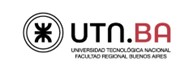

###**Trabajo Semanal 6**
**Teoria de los Circuitos 2**


Autor: Alan Nicolas Parizek


Profesor: Mariano Llamedo Soria  
Ayudante de TPs: David Moharos  
Jefe de TPs: César Fuoco  




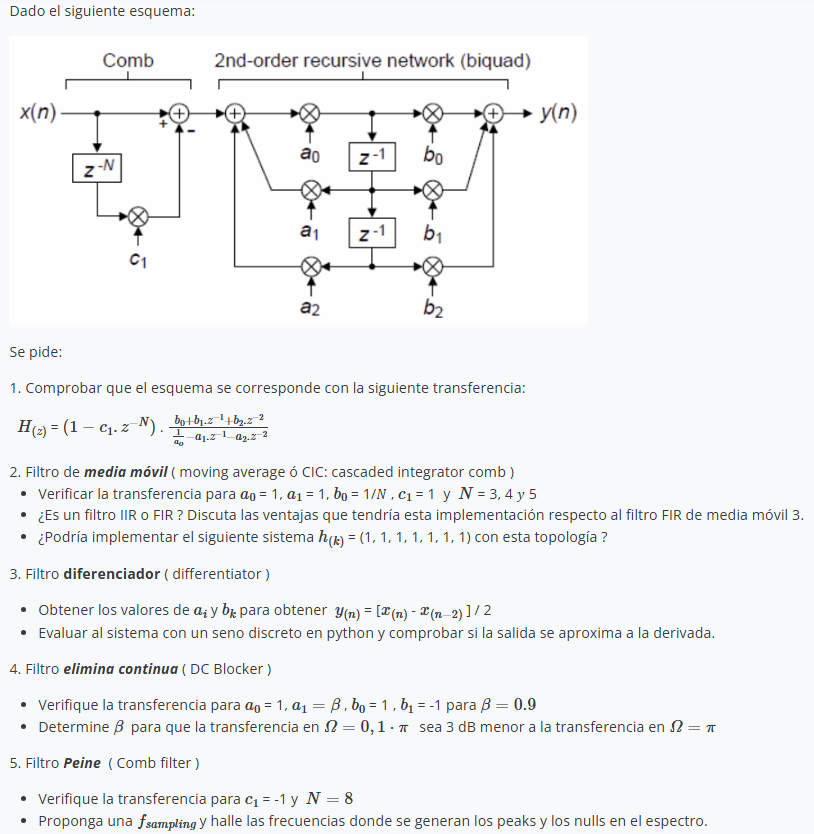

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [ ]:
def plot_zplane(b, a, title="Mapa de Polos y Ceros"):
    """
    grafica a partir de num y den
    """
    zeros, poles, _ = signal.tf2zpk(b, a)

    fig, ax = plt.subplots(figsize=(6, 6))

    theta = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), linestyle='--', color='gray', label='Círculo Unitario')


    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)


    if len(zeros) > 0:
        ax.scatter(np.real(zeros), np.imag(zeros), s=70, facecolors='none',
                   edgecolors='blue', linewidths=1.8, label=f'Ceros ({len(zeros)})', zorder=3)
    if len(poles) > 0:
        ax.scatter(np.real(poles), np.imag(poles), s=70, marker='x',
                   color='red', linewidths=1.8, label=f'Polos ({len(poles)})', zorder=3)

    max_val = max(1.2, np.max(np.abs(np.concatenate(([1.0], zeros, poles)))) * 1.1)
    ax.set_xlim([-max_val, max_val])
    ax.set_ylim([-max_val, max_val])
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle=':', alpha=0.6)

    ax.set_title(title, fontsize=12, pad=12)
    ax.set_xlabel(r'$\mathrm{Re}\{z\}$')
    ax.set_ylabel(r'$\mathrm{Im}\{z\}$')
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_freq_response(b, a=[1], fs=None, worN=1024, db=True, title="Respuesta en Frecuencia"):
    """
    Grafica la respuesta de módulo y fase de un filtro digital a partir de sus
    coeficientes de numerador (b) y denominador (a)
    """
    w, h = signal.freqz(b, a, worN=worN, fs=fs if fs else 2*np.pi)


    if fs is not None:
        freq_axis = w
        freq_label = "Frecuencia [Hz]"
    else:
        freq_axis = w / np.pi
        freq_label = r"Frecuencia normalizada $[\times \pi\ \mathrm{rad/muestra}]$"


    mag = np.abs(h)
    if db:
        mag_plot = 20 * np.log10(np.maximum(mag, 1e-6))
        mag_label = "Módulo [dB]"
    else:
        mag_plot = mag
        mag_label = "Módulo lineal |H|"

    phase = np.unwrap(np.angle(h))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    fig.suptitle(title, fontsize=13)

    ax1.plot(freq_axis, mag_plot, color='b', lw=1.8)
    ax1.set_ylabel(mag_label)
    ax1.grid(True, linestyle=':', alpha=0.6)
    if db:
        ax1.set_ylim([max(-80, np.min(mag_plot) - 5), np.max(mag_plot) + 5])

    ax2.plot(freq_axis, phase, color='r', lw=1.8)
    ax2.set_xlabel(freq_label)
    ax2.set_ylabel("Fase [rad]")
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()


## 1.


$$H(z) = H_{\text{comb}}(z) \cdot H_{\text{biquad}}(z)$$

---

### A. H1
$$w[n] = x[n] - c_1 \cdot x[n - N]$$


$$W(z) = X(z) - c_1 z^{-N} X(z) = X(z)(1 - c_1 z^{-N})$$


$$H_{\text{1}}(z) = \frac{W(z)}{X(z)} = 1 - c_1 z^{-N}$$

---

### B. H2

   $$v[n] = w[n] + a_1 \cdot (a_0 v[n-1]) + a_2 \cdot (a_0 v[n-2])$$
   $$v[n] = w[n] + a_0 a_1 v[n-1] + a_0 a_2 v[n-2]$$

   $$V(z) = W(z) + a_0 a_1 z^{-1} V(z) + a_0 a_2 z^{-2} V(z)$$
   $$V(z) \left(1 - a_0 a_1 z^{-1} - a_0 a_2 z^{-2}\right) = W(z)$$
   $$V(z) \cdot a_0 \left(\frac{1}{a_0} - a_1 z^{-1} - a_2 z^{-2}\right) = W(z)$$


   $$y[n] = b_0 (a_0 v[n]) + b_1 (a_0 v[n-1]) + b_2 (a_0 v[n-2])$$
   $$Y(z) = a_0 V(z) \left(b_0 + b_1 z^{-1} + b_2 z^{-2}\right)$$

   $$H_{\text{2}}(z) = \frac{b_0 + b_1 z^{-1} + b_2 z^{-2}}{\frac{1}{a_0} - a_1 z^{-1} - a_2 z^{-2}}$$

---




## 2.

   $$H_{\text{2}}(z) = \frac{\frac{1}{N}}{1 -  z^{-1}}.(1 - z^{-N})$$


con:
$$H(z) = \frac{1}{N} \sum_{k=0}^{N-1} z^{-k}$$

se obtiene:

* **Para $N = 3$:**
  $$H(z) = \frac{1}{3} (1 + z^{-1} + z^{-2})$$
* **Para $N = 4$:**
  $$H(z) = \frac{1}{4} (1 + z^{-1} + z^{-2} + z^{-3})$$
* **Para $N = 5$:**
  $$H(z) = \frac{1}{5} (1 + z^{-1} + z^{-2} + z^{-3} + z^{-4})$$
---

### C.
Para que el sistema tenga esa respuesta al impulso con esta configuracion necesito N=7 y $b_0=1$

Se puede ver que si la entrada es un impulso:
x(n)=[1,0,0,0,0,0,0,0]
la salida va a ser:
y(n)=[1,1,1,1,1,1,1,0]

Como la respuesta al impulso es finita, se trata de un filtro FIR.

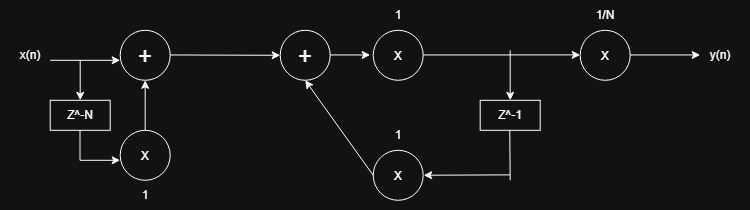

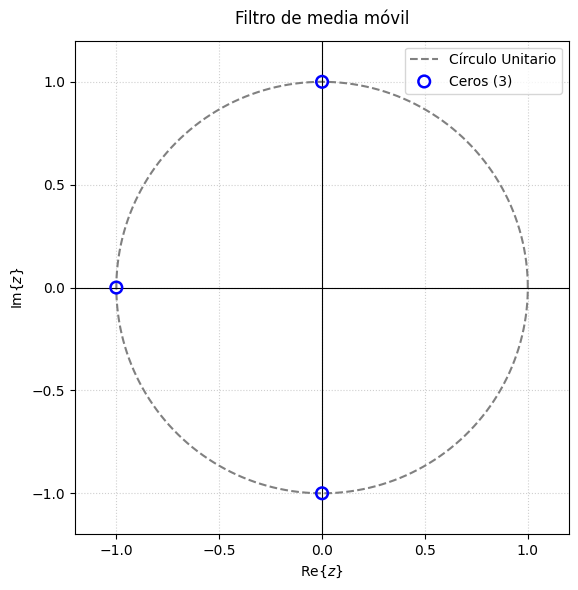

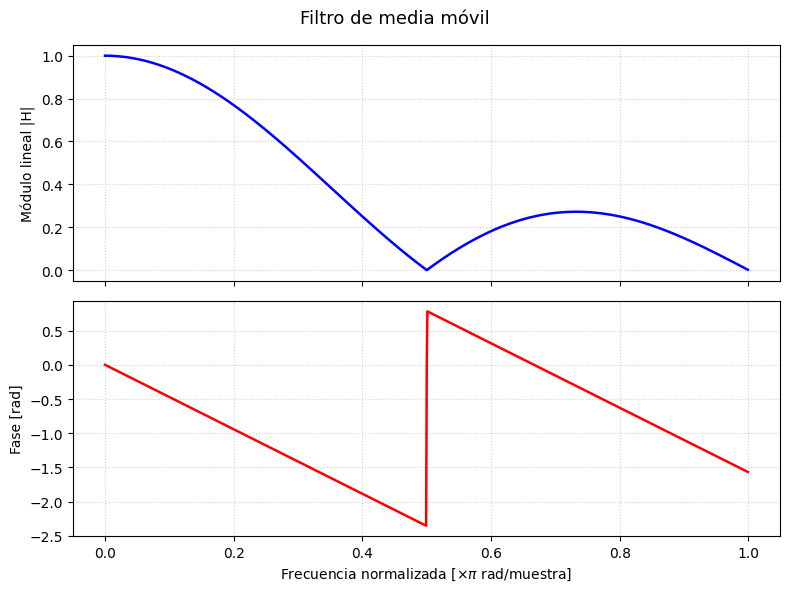

In [ ]:
b_ma = [0.25, 0.25, 0.25, 0.25]
a_ma = [1]
plot_zplane(b_ma, a_ma, title="Filtro de media móvil")
plot_freq_response(b_ma, a=[1], db=False, title="Filtro de media móvil")

## 3.

### A.

La función de transferencia objetivo es:
$$H(z) = \frac{Y(z)}{X(z)} = \frac{1}{2} - \frac{1}{2} z^{-2} = \frac{0.5 - 0.5 z^{-2}}{1}$$


**Reemplazando:**
$$\begin{cases}
a_0 = 1, & a_1 = 0, & a_2 = 0 \\
b_0 = \frac{1}{2}, & b_1 = 0, & b_2 = -\frac{1}{2} \\
c_1 = 0
\end{cases}$$





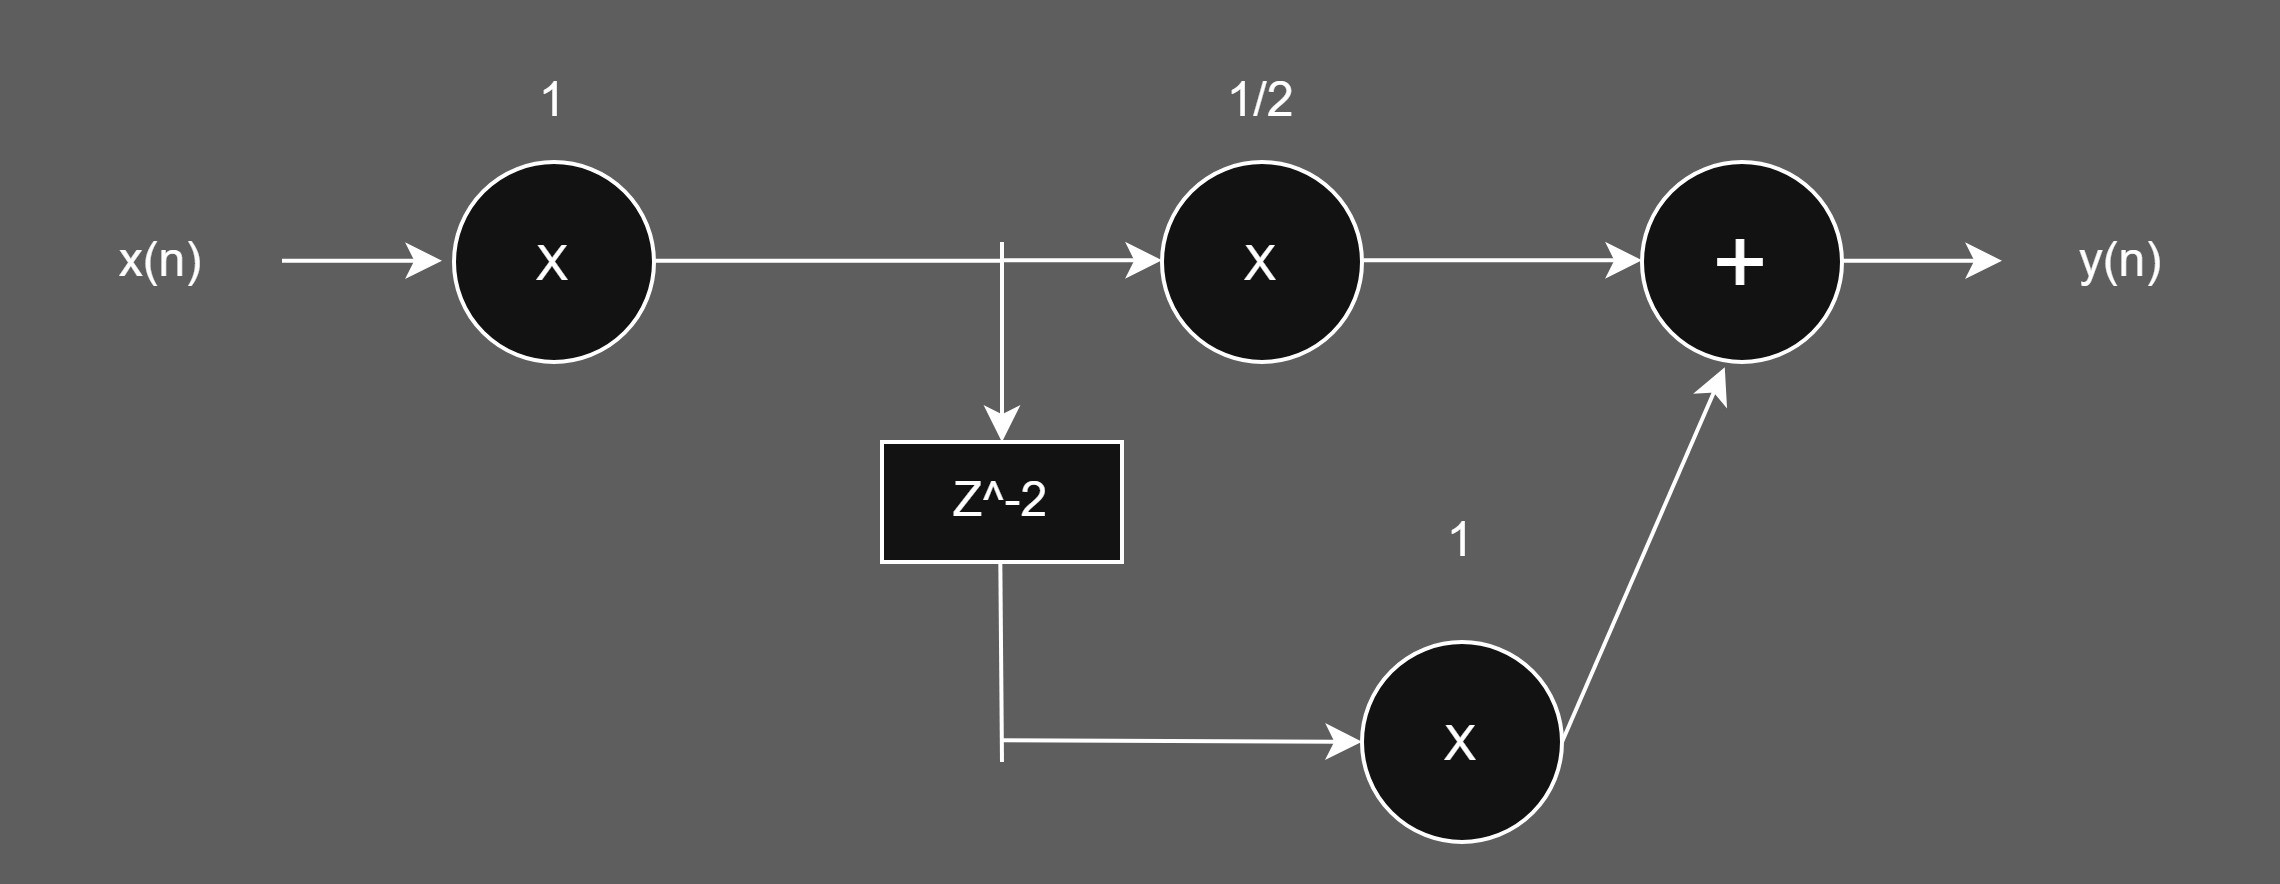

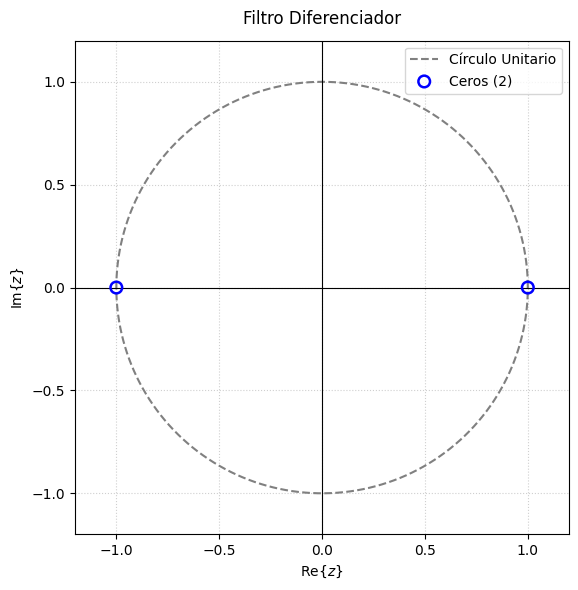

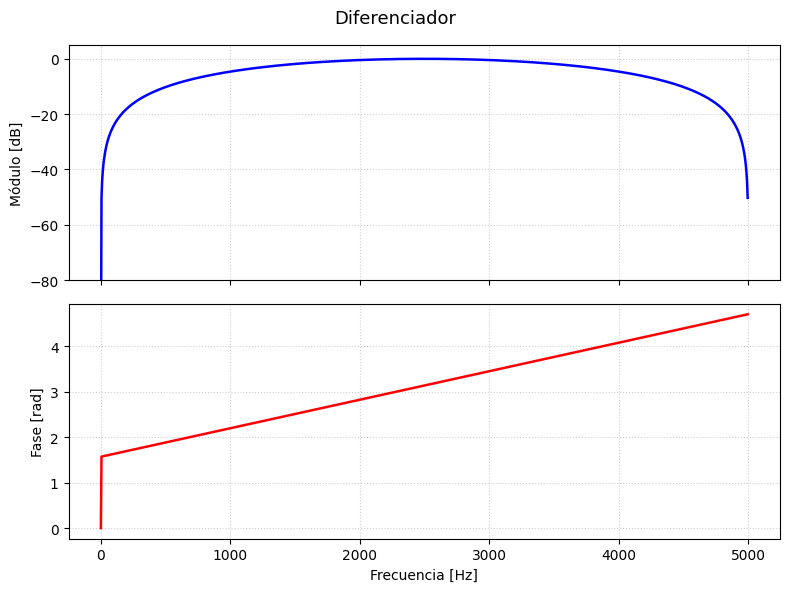

In [ ]:
b_d = [0.5, 0, -0.5]
a_d = [0, 0, 1]

plot_zplane(b_d, a_d, title="Filtro Diferenciador")
plot_freq_response(b_d, a_d, fs=10000, title="Diferenciador")

## 4.

### A
$$H(z) = \frac{1 - z^{-1}}{1 - 0.9 z^{-1}}$$




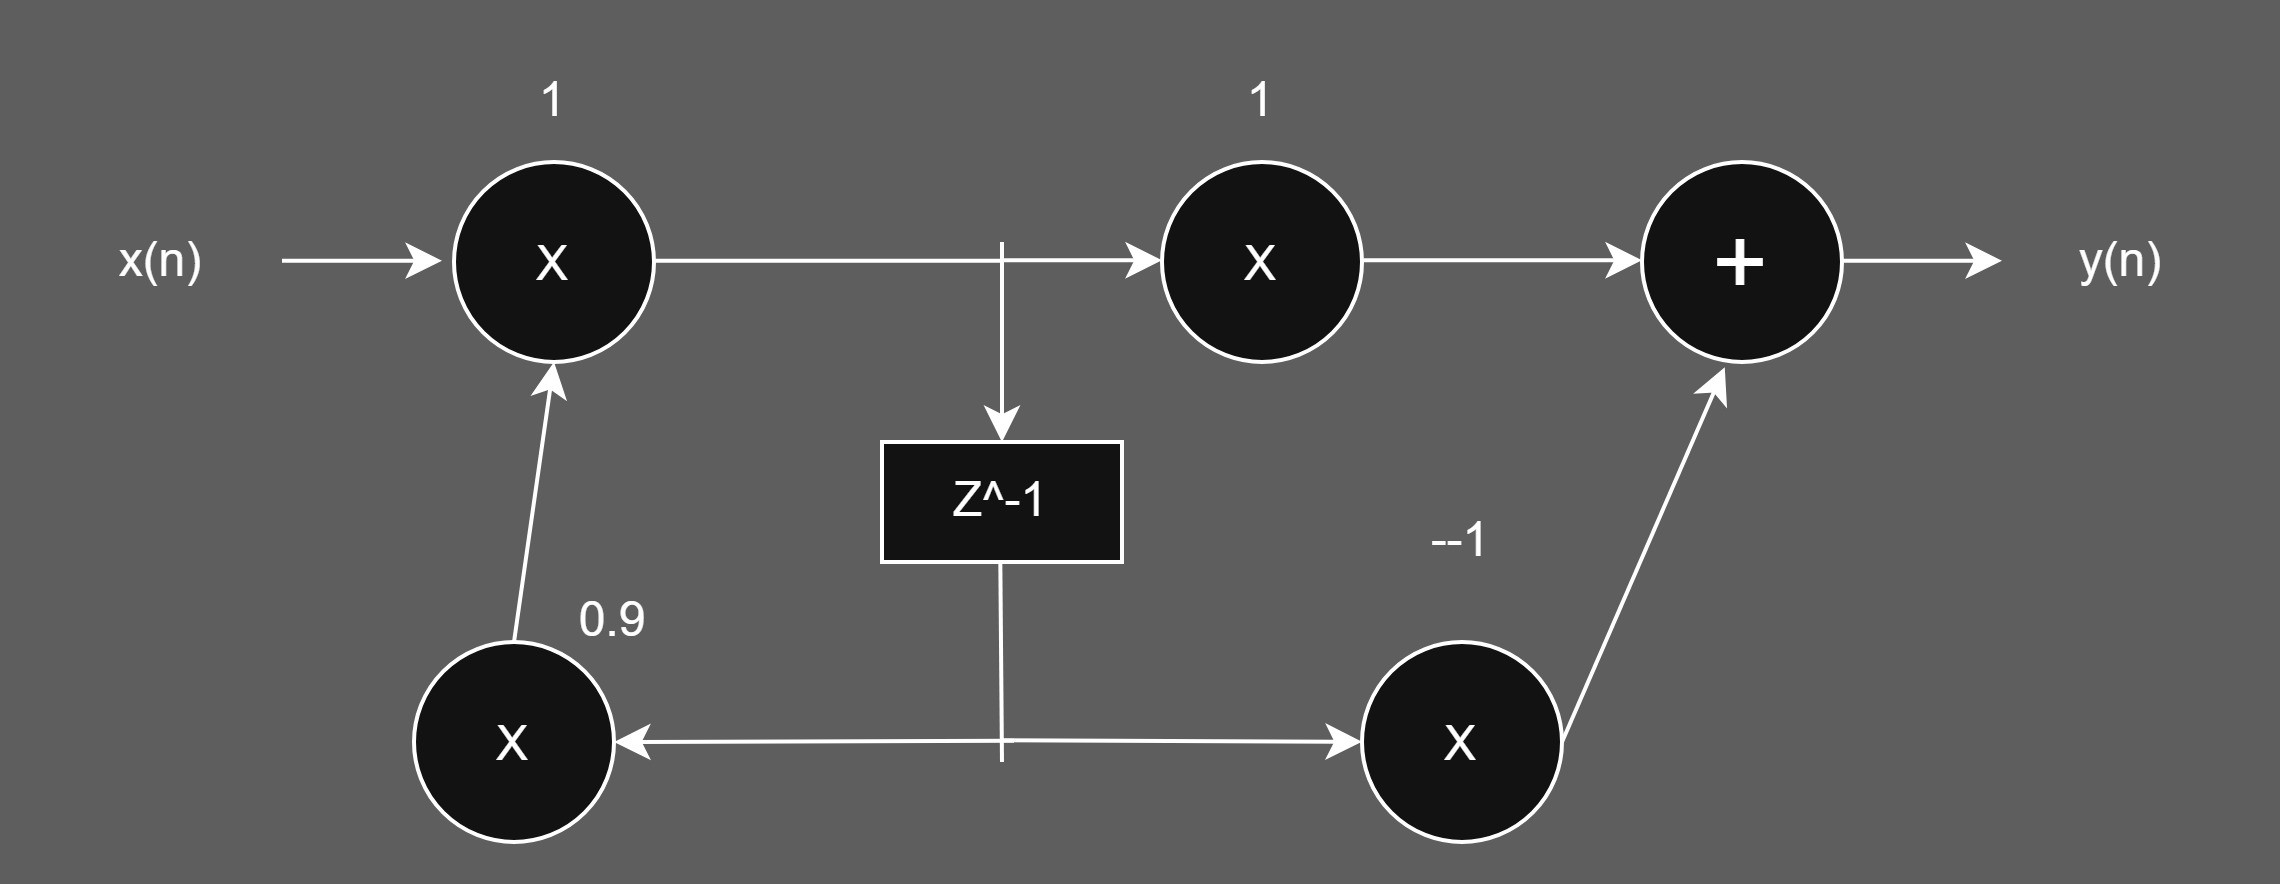

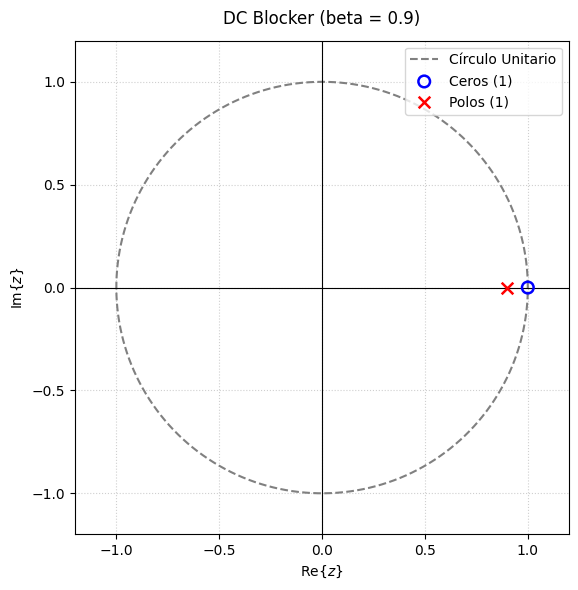

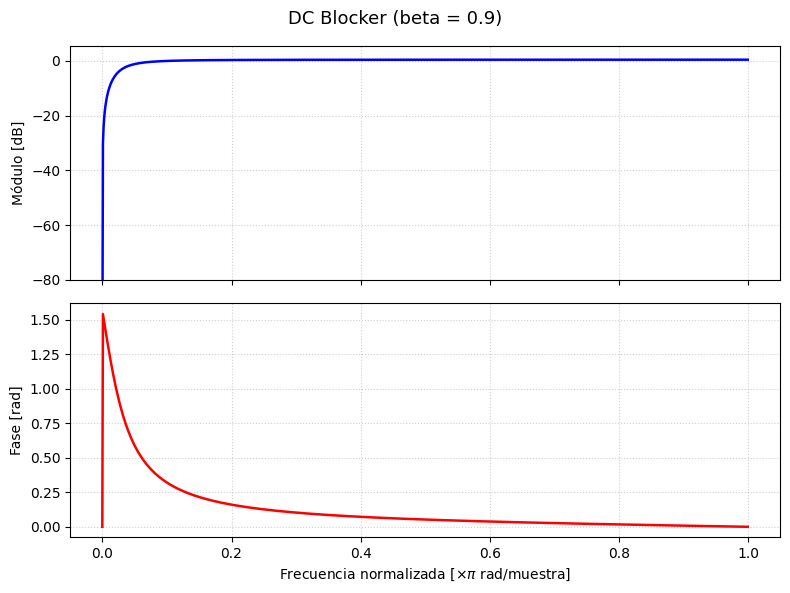

In [ ]:
b_dc = [1, -1]
a_dc = [1, -0.9]
plot_zplane(b_dc, a_dc, title="DC Blocker (beta = 0.9)")
plot_freq_response(b_dc, a_dc, title="DC Blocker (beta = 0.9)")

### B.



   $$|H(e^{j\Omega})|^2 = \frac{|1 - e^{-j\Omega}|^2}{|1 - \beta e^{-j\Omega}|^2} = \frac{2 - 2\cos(\Omega)}{1 + \beta^2 - 2\beta\cos(\Omega)}$$


   $$|H(e^{j\Omega_0})|^2 = \frac{1}{2} |H(e^{j\pi})|^2 \implies \frac{2 - 2\cos(\Omega_0)}{1 + \beta^2 - 2\beta\cos(\Omega_0)} = \frac{2}{(1 + \beta)^2}$$

   $$(1 - \cos(\Omega_0))(1 + \beta)^2 = 1 + \beta^2 - 2\beta\cos(\Omega_0)$$
   $$(1 - \cos(\Omega_0))(1 + 2\beta + \beta^2) = 1 + \beta^2 - 2\beta\cos(\Omega_0)$$


   $$\cos(\Omega_0)\,\beta^2 - 2\,\beta + \cos(\Omega_0) = 0$$

   $$\beta = \frac{2 \pm \sqrt{4 - 4\cos^2(\Omega_0)}}{2\cos(\Omega_0)} = \frac{1 \pm \sin(\Omega_0)}{\cos(\Omega_0)}$$

   con: $\Omega_0 = 0.1\pi$:
   * $\sin(0.1\pi) \approx 0.309017$
   * $\cos(0.1\pi) \approx 0.951057$

   $$\beta_1 = \frac{1 - \sin(0.1\pi)}{\cos(0.1\pi)} = \frac{1 - 0.309017}{0.951057} \approx 0.7265$$
   $$\beta_2 = \frac{1 + \sin(0.1\pi)}{\cos(0.1\pi)} \approx 1.3764$$


   $$\beta = \frac{1 - \sin(0.1\pi)}{\cos(0.1\pi)} \approx 0.7265$$

---

## 5

$$H(z) = 1 - c_1 z^{-N} = 1 - (-1)z^{-8} = 1 + z^{-8}$$


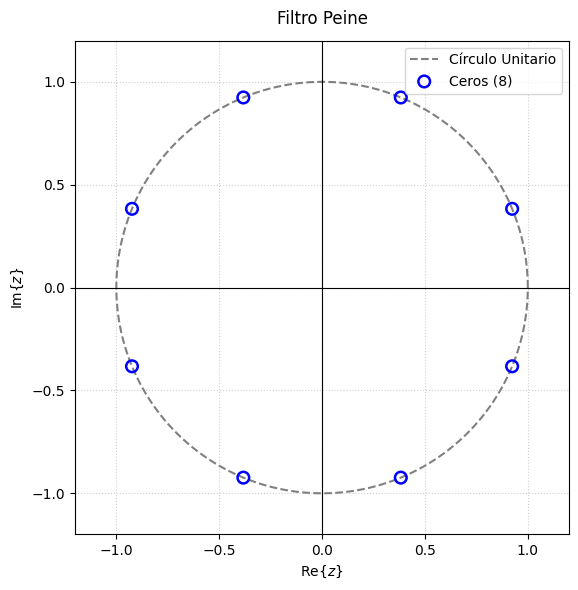

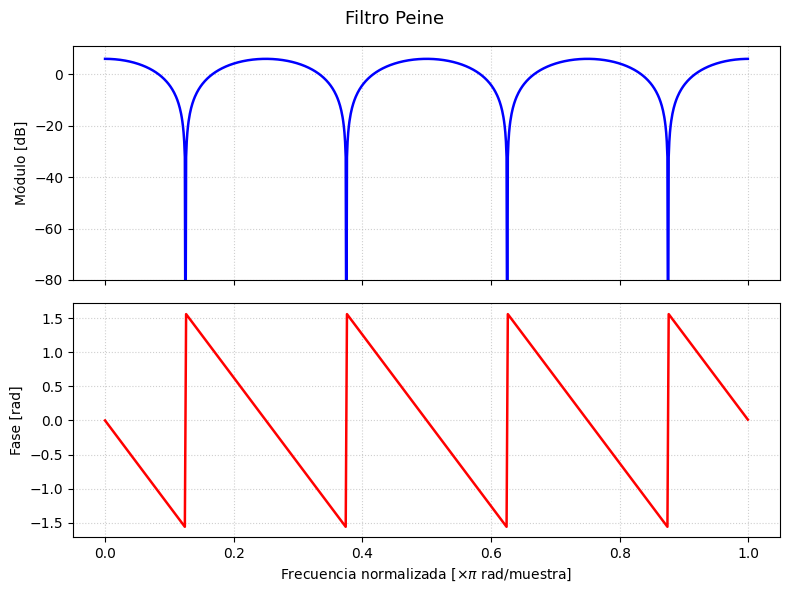

In [ ]:
b_comb = [1] + [0]*7 + [1]
a_comb = [1]
plot_zplane(b_comb, a_comb, title="Filtro Peine")
plot_freq_response(b_comb, a_comb, db=True, title="Filtro Peine")

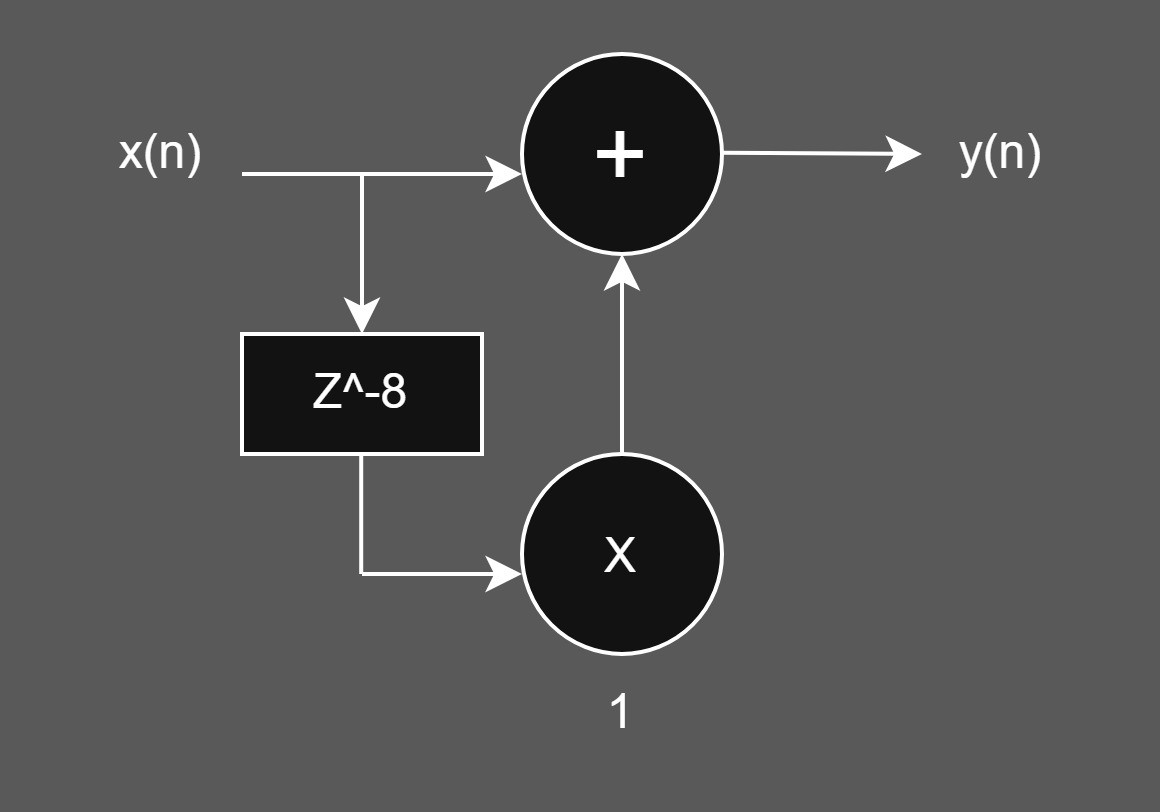


### B. Picos y Nulos en el espectro

$$H(e^{j\omega}) = 1 + e^{-j8\omega} = e^{-j4\omega} \left(e^{j4\omega} + e^{-j4\omega}\right) = 2\cos(4\omega) e^{-j4\omega}$$

Los nulls ocurren cuando $$cos(4\omega)=0$$

entonces:

$$4\omega = \frac{\pi}{2} + k\pi \implies \omega_k = \frac{(2k + 1)\pi}{8} \quad \text{para } k = 0, 1, 2, 3$$

Los peaks ocurren cuando $$cos(4\omega)=1$$

entonces

$$4\omega = m\pi \implies \omega_m = \frac{m\pi}{4} \quad \text{para } m = 0, 1, 2, 3, 4$$

---

### C.

Para $$f_s = 10\text{ kHz}$$:

Nulls:
* $k = 0 \implies \mathbf{625\text{ Hz}}$
* $k = 1 \implies \mathbf{1875\text{ Hz}}$
* $k = 2 \implies \mathbf{3125\text{ Hz}}$
* $k = 3 \implies \mathbf{4375\text{ Hz}}$

Peaks:

* $m = 0 \implies \mathbf{0\text{ Hz}}$
* $m = 1 \implies \mathbf{1250\text{ Hz}}$
* $m = 2 \implies \mathbf{2500\text{ Hz}}$
* $m = 3 \implies \mathbf{3750\text{ Hz}}$
* $m = 4 \implies \mathbf{5000\text{ Hz}}$
